In [1]:
# Ячейка № 1

# подключение библиотеки numpy
import numpy as np

# подключение метода solve_ivp
# из библиотеки scipy.integrate
from scipy.integrate import solve_ivp

# подключение библиотеки matplotlib
import matplotlib.pyplot as plt

In [2]:
# Ячейка № 2

# задание функции,
# возвращающей значения
# первых производных в (8.67)
def Oscillator(t, z):
    # инициализация массива, используемого для
    # хранения значений первых производных
    dy = np.zeros(2)

    dy[0] = z[1]
    dy[1] = a / L * Gg**2 * np.sin(Gg * t) * np.cos(z[0]) - g / L * np.sin(z[0])
    return dy

In [ ]:
# Ячейка № 3

# задание функции, возвращающей
# значения координат узлов ВС,
# использованной для вычисления
# численного решения СДУ (8.67)
# x=x(t), y=y(t)
def Solv_ODE(phi0, dphi_dt0, Tmax, t):
    # вычисление численного решения СДУ (8.67)
    # в узлах ВС, координаты которых
    # размещены в массиве t
    Solv = solve_ivp(
        Oscillator,
        [0, Tmax],
        [phi0, dphi_dt0],
        t_eval=t,
        method="RK45",
        rtol=1e-8,
        atol=1e-8,
    )

    # размещение значений координат узлов
    # временной сетки, на которой найдены численные решения
    # системы ОДУ (8.67) в массив t
    t = Solv.t

    # размещение мгновенных значений
    # угла отклонения математического маятника
    # от вертикали в массив phi
    phi = Solv.y[0, :]

    # размещение мгновенных значений
    # угловой скорости математического маятника
    # составляющей скорости в массив dphi_dt
    dphi_dt = Solv.y[1, :]

    return phi, dphi_dt

In [4]:
# Ячейка № 4

# задание функции, возвращающей
# значения декартовых координат
# маятника с колеблющейся точкой подвеса
def Coordinates(phi):
    # определение числа узлов временной сетки
    Np1 = len(phi)

    # инициализация массивов, используемых
    # для хранения мгновенных значений
    # декартовых координат и энергии математического маятника.
    x1 = np.zeros(Np1)
    y1 = np.zeros(Np1)

    # вычисление декартовых координат
    # математического маятника
    for i in range(Np1):
        # Квадрант I
        if (phi[i] >= 0) & (phi[i] >= np.pi / 2):
            x1[i] = L * np.sin(np.pi - phi[i])
            y1[i] = L * np.cos(np.pi - phi[i])
        # Квадрант II
        if (phi[i] < 0) & (np.abs(phi[i]) >= np.pi / 2):
            x1[i] = -L * np.sin(np.pi - np.abs(phi[i]))
            y1[i] = L * np.cos(np.pi - np.abs(phi[i]))
        # Квадрант III
        if (phi[i] < 0) & (np.abs(phi[i]) < np.pi / 2):
            x1[i] = -L * np.sin(np.abs(phi[i]))
            y1[i] = -L * np.cos(np.abs(phi[i]))
        # Квадрант IV
        if (phi[i] > 0) & (phi[i] <= np.pi / 2):
            x1[i] = L * np.sin(phi[i])
            y1[i] = -L * np.cos(phi[i])
        x1[i] = x1[i] + a * np.sin(Gg * t[i])

    return x1, y1

In [ ]:
# Ячейка № 5

# задание значения
# ускорения свободного падения
g = 9.8

# задание длины маятника
L = 0.5

# задание амплитуды колебаний точки подвеса
a = 0.1

# задание частоты колебаний точки подвеса
Gg = 5

# задание начального угла отклонения
# математического маятника от вертикали
phi0 = 0.6  # 1.5

# задание начального значения скорости
# математического маятника
dphi_dt0 = 0

# задание длительности временного интервала,
# на котором вычисляется численное решение СДУ (8.67)
Tmax = 10

# задание числа узлов ВС
N = 10**4

# задание ВС, в узлах которой
# вычисляется численное решение СДУ (8.67)
t = np.linspace(0, Tmax, N)

# вычисление значения шага ВС
dt = t[1] - t[0]

# вычисление численного решения СДУ (8.67)
phi, dphi_dt = Solv_ODE(phi0, dphi_dt0, Tmax, t)


# вычисление координат маятника
# с учетом номера квадранта, в котором
# находится
x, y = Coordinates(phi)

# вычисление траектории движения маятника
# для начального угла phi2=-phi0
# задание начального угла отклонения
# математического маятника от вертикали
phi0 = -phi0

# задание амплитуды колебаний точки подвеса
a = -a

# вычисление численного решения СДУ (8.67)
phi2, dphi_dt2 = Solv_ODE(phi0, dphi_dt0, Tmax, t)

x2, y2 = Coordinates(phi2)

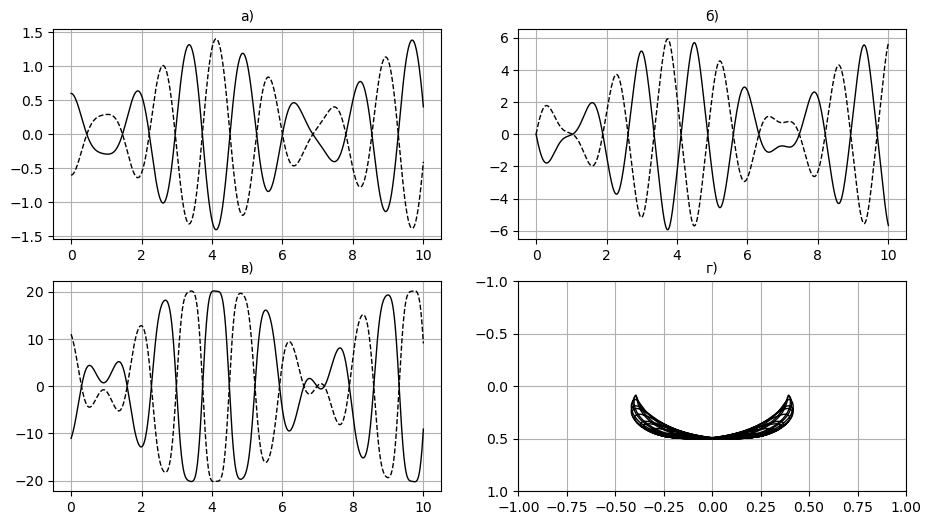

In [ ]:
# Ячейка № 6

# визуализация зависимостей углов,
# угловых скоростей и угловых
# ускорений от времени, траекторий
# движения маятника с различными
# начальными условиями

fig = plt.figure(figsize=(11, 6))

# визуализация зависимостей угла
# отклонения маятника от оси OY
ax1 = fig.add_subplot(2, 2, 1)
ax1.plot(t, phi, "-k", lw=1)
ax1.plot(t, phi2, "--k", lw=1)
ax1.grid(True)
ax1.set_title("а)", fontsize=10)

ax2 = fig.add_subplot(2, 2, 2)

# визуализация зависимостей
# угловых скоростей
# маятника от времени
ax2.plot(t, dphi_dt, "-k", lw=1)
ax2.plot(t, dphi_dt2, "--k", lw=1)
ax2.grid(True)
ax2.set_title("б)", fontsize=10)

ax3 = fig.add_subplot(2, 2, 3)
# визуализация зависимостей
# угловых ускорений маятника
# от времени
ax3.plot(t[1 : len(t) - 2], np.diff(dphi_dt)[1 : len(t) - 2] / dt, "-k", lw=1)
ax3.plot(t[1 : len(t) - 2], np.diff(dphi_dt2)[1 : len(t) - 2] / dt, "--k", lw=1)
ax3.grid(True)
ax3.set_title("в)", fontsize=10)

ax4 = fig.add_subplot(2, 2, 4)
# визуализация траекторий
# движения маятника
ax4.plot(x, -y, "-k", lw=1)
ax4.plot(x2, -y2, "-k", lw=1)
ax4.set_ylim(1, -1)
ax4.set_xlim(-1, 1)
ax4.grid(True)
ax4.set_title("г)", fontsize=10)

plt.show()

In [7]:
a**2 * Gg**2 / (2 * g * L)


0.025510204081632657